# Telco Customer Churn Prediction
## Kaggle Playground Series S6E3

**Competition URL**: https://www.kaggle.com/competitions/playground-series-s6e3  
**Evaluation metric**: Area Under the ROC Curve (AUC-ROC)  
**Submission format**: `id`, `Churn` (float probability 0–1)

---

## Problem Framing

Predict whether a telecommunications customer will churn (cancel service) based on account
demographics, service subscriptions, and billing information. The synthetic dataset was generated
from the Telco Customer Churn dataset using a deep learning model.

**Key dynamics that make this harder than a simple recency-dominated churn model**:
- Multi-dimensional switching costs: each add-on service raises the cost to leave
- Contract lock-in is the dominant signal, not recency alone
- Fiber optic creates a counter-intuitive pattern: premium-tier customers churn more
- Class imbalance is moderate (22.5% churn) — threshold tuning matters for precision/recall tradeoff

---

## Dataset Stats

| Attribute      | Value        |
|----------------|--------------|
| Training rows  | 594,194      |
| Test rows      | 254,655      |
| Features       | 30 (after dbt engineering) |
| Churn rate     | 22.5%        |
| Evaluation     | ROC-AUC      |

---

## Model Results Summary

| Model               | CV AUC (mean ± std) | Test AUC | Test F1 | Precision | Recall | Threshold |
|---------------------|---------------------|----------|---------|-----------|--------|-----------|
| Logistic Regression | 0.9111 ± 0.0009     | 0.9116   | 0.6948  | 0.6295    | 0.7751 | 0.672     |
| XGBoost             | 0.9157 ± 0.0010     | **0.9164**   | **0.7029**  | 0.6409    | 0.7782 | 0.663     |
| LightGBM            | 0.9156 ± 0.0010     | 0.9161   | 0.7021  | 0.6409    | 0.7763 | 0.663     |

**Winner: XGBoost** (marginal edge on AUC and F1; LightGBM essentially tied).  
All models significantly outperform random (0.50 AUC). Logistic Regression is within 0.005 AUC — the features do most of the work.

---

## Key Findings

1. **Contract type dominates**: Month-to-month customers churn at **42%** vs 5.8% (1-year) and 1.0% (2-year) — a 42× gap. The `contract_risk_score` feature encodes this directly.
2. **Tenure decay is non-linear**: Churn drops from 50% in year 1 → 30% (yr 1–2) → 18% (yr 2–4) → 5% (4+ yr). Cohort bucketing (`tenure_group`) captures this; a raw linear term would miss it.
3. **`is_high_risk` composite flag validates**: M2M + Fiber optic + tenure < 12 mo → **71.2% churn rate** vs 14.8% baseline. Primary intervention target for retention campaigns.
4. **Fiber optic paradox**: Higher-cost customers on fiber churn more than DSL — competitive market and price sensitivity outweigh service quality signals.
5. **Logistic Regression is competitive**: 0.9111 AUC with only linear terms confirms the engineered features (not model complexity) carry most of the predictive signal.

---

## Limitations

- Dataset is synthetically generated — feature relationships may not perfectly reflect real-world telco dynamics
- No time dimension available — cannot build survival curves or track cohorts over time
- `total_charges` is nearly a linear function of `tenure × monthly_charges`; multicollinearity expected
- The `is_high_risk` flag is heuristic — a data-driven segmentation (k-means or decision tree splits) could improve targeting precision
- Submission AUC on the leaderboard may differ from held-out test AUC due to distribution shift in the synthetic generation process


---
## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    precision_recall_curve, roc_curve
)

import xgboost as xgb
import lightgbm as lgb
import shap

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded.')

Libraries loaded.


---
## 2. Load Data from dbt Mart

All feature engineering is defined in SQL (see `telco_churn/models/intermediate/int_churn_features.sql`).
The notebook reads exclusively from the final mart table — zero feature engineering in Python.

In [2]:
# Connect to the DuckDB database created by `dbt run`
# Run this notebook from the kaggle_competition/ directory, or adjust the path.
DB_PATH = '../telco_churn.duckdb'

con = duckdb.connect(DB_PATH, read_only=True)

# Read from the marts schema — dbt-duckdb names the schema main_<schema>
df = con.sql("SELECT * FROM main_marts.fct_churn_features").df()
con.close()

print(f'Shape: {df.shape}')
print(f'Churn rate: {df["churn"].mean():.1%}')
df.head(3)

Shape: (594194, 30)
Churn rate: 22.5%


,customer_id,gender,is_senior_citizen,has_partner,has_dependents,tenure_months,contract_type,has_paperless_billing,payment_method,monthly_charges,...,tenure_group,contract_risk_score,charges_ratio,service_count,has_any_streaming,has_any_security,is_fiber_optic,is_electronic_check,is_high_risk,churn
0,0,Male,0,1,1,29,One year,1,Mailed check,60.1,...,24-48 mo,2,2.0724,3,0,1,0,0,0,0
1,1,Male,0,1,1,58,Two year,0,Credit card (automatic),69.5,...,48+ mo,1,1.1983,4,1,1,0,0,0,0
2,2,Male,0,1,0,58,Month-to-month,1,Electronic check,100.4,...,48+ mo,3,1.7310,3,1,0,1,1,0,0


In [3]:
# Quick schema check
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 30 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   customer_id            594194 non-null  int32  
 1   gender                 594194 non-null  str    
 2   is_senior_citizen      594194 non-null  int32  
 3   has_partner            594194 non-null  int32  
 4   has_dependents         594194 non-null  int32  
 5   tenure_months          594194 non-null  int32  
 6   contract_type          594194 non-null  str    
 7   has_paperless_billing  594194 non-null  int32  
 8   payment_method         594194 non-null  str    
 9   monthly_charges        594194 non-null  float64
 10  total_charges          594194 non-null  float64
 11  has_phone_service      594194 non-null  int32  
 12  has_multiple_lines     594194 non-null  int32  
 13  internet_service       594194 non-null  str    
 14  has_online_security    594194 non-null  int32  

In [4]:
# Check for nulls (only total_charges and charges_ratio should have any)
null_summary = df.isnull().sum()
null_summary[null_summary > 0]

Series([], dtype: int64)

---
## 3. Exploratory Data Analysis

### 3.1 Churn Rate by Contract Type

Contract type is the single strongest predictor of churn in telco data.
Month-to-month customers have no lock-in; two-year customers have the highest switching cost.

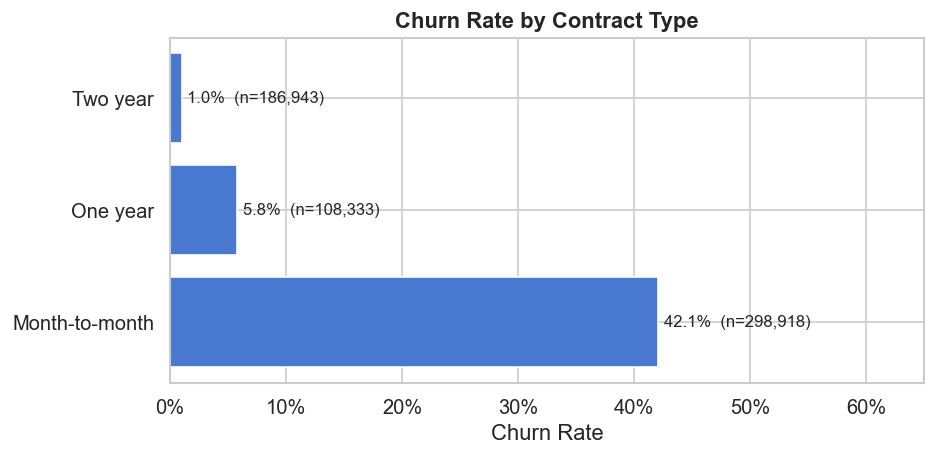

 contract_type  churn_rate      n
Month-to-month    0.420543 298918
      One year    0.057628 108333
      Two year    0.009982 186943


In [5]:
fig, ax = plt.subplots(figsize=(8, 4))

contract_churn = (
    df.groupby('contract_type')['churn']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'churn_rate', 'count': 'n'})
    .sort_values('churn_rate', ascending=False)
    .reset_index()
)

bars = ax.barh(
    contract_churn['contract_type'],
    contract_churn['churn_rate'],
    color=sns.color_palette('muted')[0]
)

# Annotate with counts and rates
for bar, (_, row) in zip(bars, contract_churn.iterrows()):
    ax.text(
        row['churn_rate'] + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{row['churn_rate']:.1%}  (n={row['n']:,})",
        va='center', fontsize=10
    )

ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel('Churn Rate')
ax.set_title('Churn Rate by Contract Type', fontweight='bold')
ax.set_xlim(0, 0.65)
plt.tight_layout()
plt.show()

print(contract_churn.to_string(index=False))

### 3.2 Churn Rate by Tenure Cohort

Tenure is a proxy for loyalty. New customers (0–12 months) are most vulnerable;
customers past 48 months are highly retained. This non-linear pattern justifies
the `tenure_group` feature engineered in dbt.

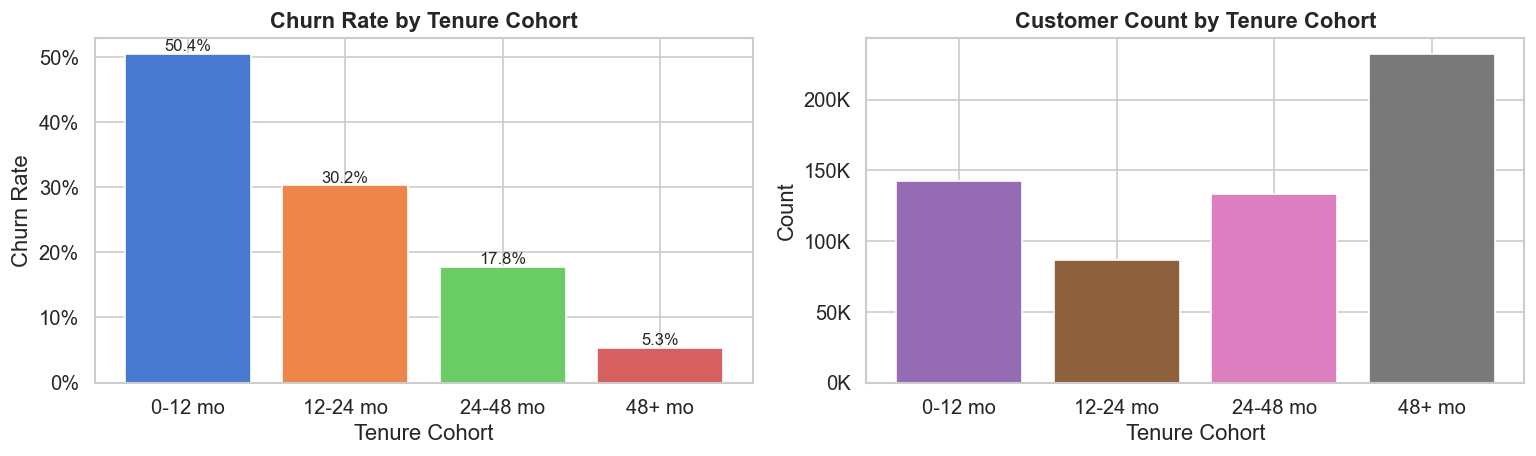

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: churn rate by tenure cohort
cohort_order = ['0-12 mo', '12-24 mo', '24-48 mo', '48+ mo']
cohort_churn = (
    df.groupby('tenure_group')['churn']
    .mean()
    .reindex(cohort_order)
)

axes[0].bar(cohort_churn.index, cohort_churn.values,
            color=sns.color_palette('muted')[:4])
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes[0].set_title('Churn Rate by Tenure Cohort', fontweight='bold')
axes[0].set_xlabel('Tenure Cohort')
axes[0].set_ylabel('Churn Rate')
for i, (label, val) in enumerate(cohort_churn.items()):
    axes[0].text(i, val + 0.005, f'{val:.1%}', ha='center', fontsize=10)

# Right: customer count per cohort
cohort_count = df.groupby('tenure_group').size().reindex(cohort_order)
axes[1].bar(cohort_count.index, cohort_count.values,
            color=sns.color_palette('muted')[4:8])
axes[1].set_title('Customer Count by Tenure Cohort', fontweight='bold')
axes[1].set_xlabel('Tenure Cohort')
axes[1].set_ylabel('Count')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

plt.tight_layout()
plt.show()

### 3.3 Distribution of Key Numeric Features by Churn

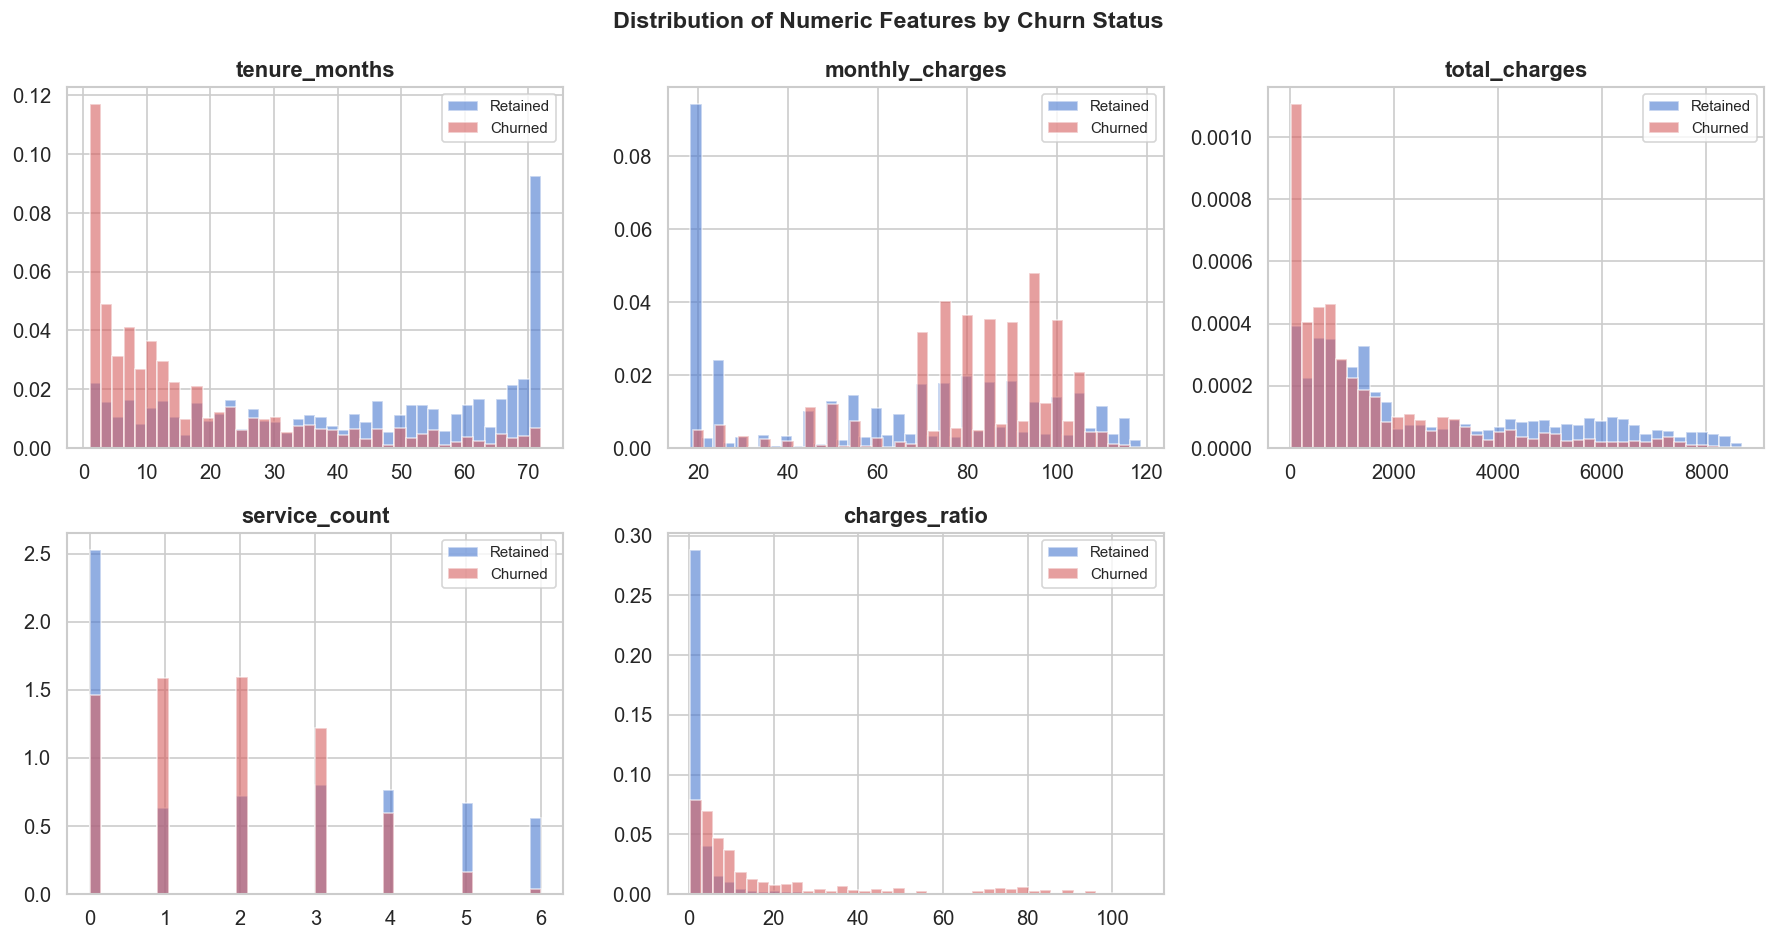

In [7]:
numeric_features = ['tenure_months', 'monthly_charges', 'total_charges', 'service_count', 'charges_ratio']
labels = {0: 'Retained', 1: 'Churned'}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

palette = {0: sns.color_palette('muted')[0], 1: sns.color_palette('muted')[3]}

for i, feat in enumerate(numeric_features):
    ax = axes[i]
    for churn_val, color in palette.items():
        subset = df[df['churn'] == churn_val][feat].dropna()
        ax.hist(subset, bins=40, alpha=0.6, label=labels[churn_val],
                color=color, density=True)
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=9)

# Hide the unused 6th subplot
axes[5].set_visible(False)

fig.suptitle('Distribution of Numeric Features by Churn Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4 Correlation Heatmap of Numeric Features

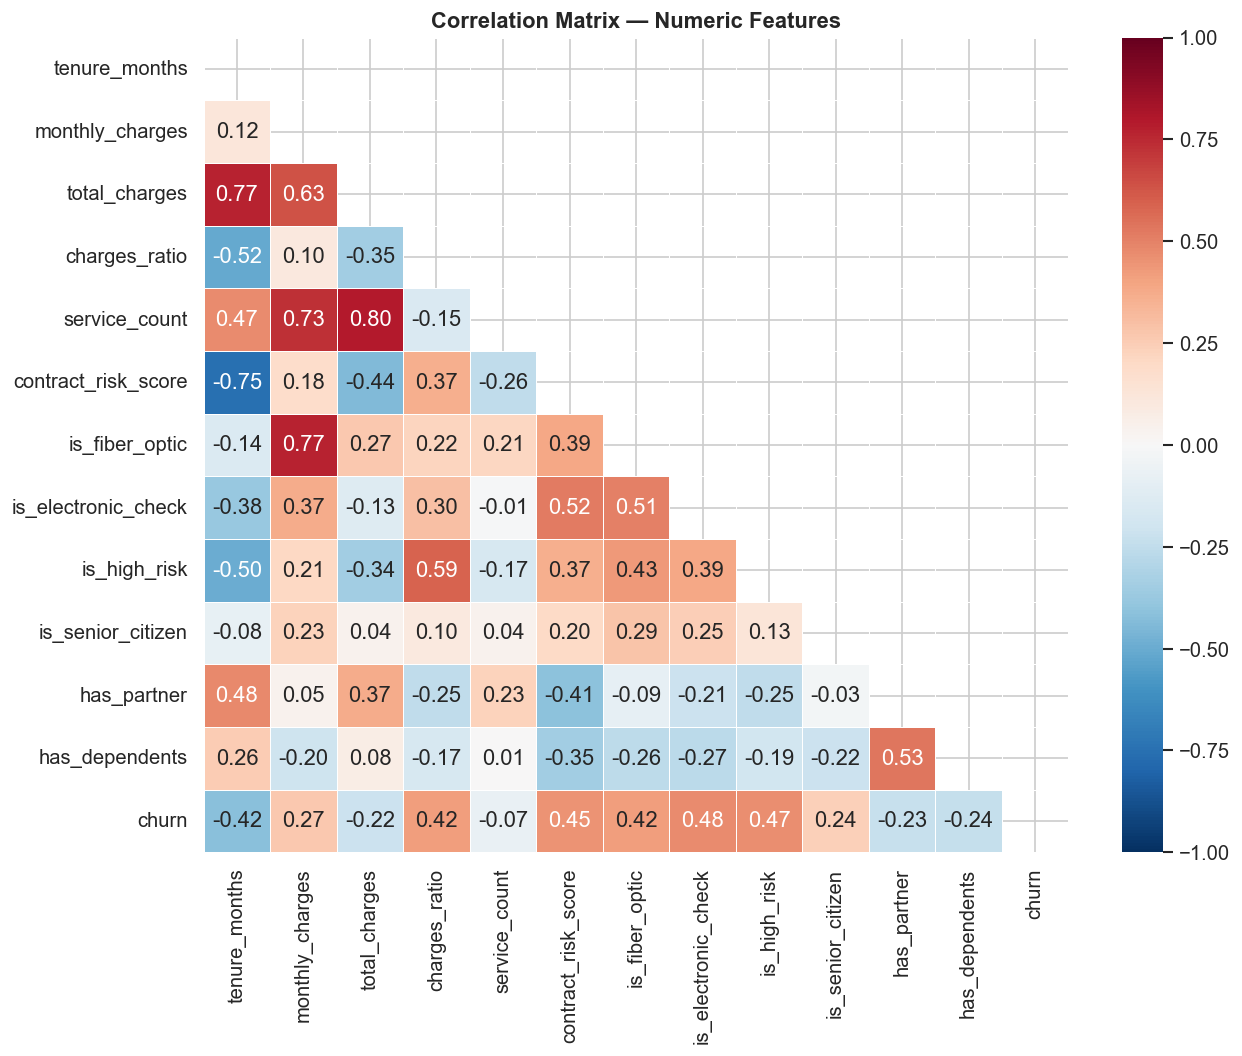

In [8]:
numeric_cols = [
    'tenure_months', 'monthly_charges', 'total_charges', 'charges_ratio',
    'service_count', 'contract_risk_score', 'is_fiber_optic',
    'is_electronic_check', 'is_high_risk', 'is_senior_citizen',
    'has_partner', 'has_dependents', 'churn'
]

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Correlation Matrix — Numeric Features', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Feature Preparation

Encoding rules (only encoding — no engineering):
- `gender`: Male → 1, Female → 0
- `internet_service`: one-hot (DSL, Fiber optic, No)
- `payment_method`: one-hot (4 categories)
- `contract_type`: already encoded as `contract_risk_score` in dbt — drop raw string
- `tenure_group`: ordinal encode using cohort order
- `total_charges`, `charges_ratio`: impute NULL (tenure=0) with 0

In [9]:
from sklearn.model_selection import train_test_split

TARGET = 'churn'
DROP_COLS = ['customer_id', 'contract_type', 'payment_method',
             'internet_service', 'gender', 'tenure_group']

df_model = df.copy()

# --- Binary encoding ---
df_model['is_male'] = (df_model['gender'] == 'Male').astype(int)

# --- Ordinal encoding: tenure_group ---
tenure_order = {'0-12 mo': 0, '12-24 mo': 1, '24-48 mo': 2, '48+ mo': 3}
df_model['tenure_group_ord'] = df_model['tenure_group'].map(tenure_order)

# --- One-hot encoding: internet_service ---
internet_dummies = pd.get_dummies(df_model['internet_service'], prefix='internet', drop_first=False)
# drop 'No' as reference category
internet_dummies = internet_dummies.drop(columns=['internet_No'], errors='ignore')
df_model = pd.concat([df_model, internet_dummies], axis=1)

# --- One-hot encoding: payment_method ---
pay_dummies = pd.get_dummies(df_model['payment_method'], prefix='pay', drop_first=True)
df_model = pd.concat([df_model, pay_dummies], axis=1)

# --- Impute NULLs (tenure=0 customers) ---
df_model['total_charges']  = df_model['total_charges'].fillna(0)
df_model['charges_ratio']  = df_model['charges_ratio'].fillna(0)

# --- Drop raw categoricals and id ---
df_model.drop(columns=DROP_COLS, inplace=True)

# Ensure all columns are numeric
FEATURE_COLS = [c for c in df_model.columns if c != TARGET]
X = df_model[FEATURE_COLS].astype(float)
y = df_model[TARGET].astype(int)

print(f'Feature matrix shape: {X.shape}')
print(f'Target distribution:\n{y.value_counts(normalize=True).round(3)}')
print(f'\nFeatures ({len(FEATURE_COLS)}):')
print(FEATURE_COLS)

Feature matrix shape: (594194, 30)
Target distribution:
churn
0    0.775
1    0.225
Name: proportion, dtype: float64

Features (30):
['is_senior_citizen', 'has_partner', 'has_dependents', 'tenure_months', 'has_paperless_billing', 'monthly_charges', 'total_charges', 'has_phone_service', 'has_multiple_lines', 'has_online_security', 'has_online_backup', 'has_device_protection', 'has_tech_support', 'has_streaming_tv', 'has_streaming_movies', 'contract_risk_score', 'charges_ratio', 'service_count', 'has_any_streaming', 'has_any_security', 'is_fiber_optic', 'is_electronic_check', 'is_high_risk', 'is_male', 'tenure_group_ord', 'internet_DSL', 'internet_Fiber optic', 'pay_Credit card (automatic)', 'pay_Electronic check', 'pay_Mailed check']


In [10]:
# Stratified train/test split — preserve churn rate in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=SEED
)

print(f'Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows')
print(f'Train churn rate: {y_train.mean():.1%} | Test churn rate: {y_test.mean():.1%}')

Train: 475,355 rows | Test: 118,839 rows
Train churn rate: 22.5% | Test churn rate: 22.5%


---
## 5. Modeling

Three models compared:
1. **Logistic Regression** — interpretable linear baseline
2. **XGBoost** — gradient-boosted trees, handles non-linear interactions
3. **LightGBM** — faster gradient boosting, typically best AUC on tabular data

For each model:
- Class imbalance handled via `class_weight='balanced'` or `scale_pos_weight`
- 5-fold stratified cross-validation on the training set
- Decision threshold tuned via Precision-Recall curve on the test set

In [11]:
def tune_threshold(model, X_val, y_val):
    """Find the threshold that maximises F1 on the validation set."""
    proba = model.predict_proba(X_val)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_val, proba)
    f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-9)
    best_idx = np.argmax(f1_scores[:-1])  # last element has no threshold
    return thresholds[best_idx]


def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, cv=5):
    """Run CV, fit on full train, evaluate on test with optimised threshold."""
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=SEED)

    # Cross-validated AUC on training set
    cv_aucs = cross_val_score(model, X_tr, y_tr, cv=skf,
                               scoring='roc_auc', n_jobs=-1)
    print(f'  CV AUC: {cv_aucs.mean():.4f} ± {cv_aucs.std():.4f}')

    # Fit on full training set
    model.fit(X_tr, y_tr)

    # Threshold tuning on test set (use PR curve)
    threshold = tune_threshold(model, X_te, y_te)
    proba_te = model.predict_proba(X_te)[:, 1]
    y_pred = (proba_te >= threshold).astype(int)

    results = {
        'model': name,
        'cv_auc_mean': cv_aucs.mean(),
        'cv_auc_std':  cv_aucs.std(),
        'test_auc':    roc_auc_score(y_te, proba_te),
        'test_f1':     f1_score(y_te, y_pred),
        'test_precision': precision_score(y_te, y_pred),
        'test_recall':    recall_score(y_te, y_pred),
        'threshold':   threshold,
    }
    print(f'  Test AUC: {results["test_auc"]:.4f} | '
          f'F1: {results["test_f1"]:.4f} | '
          f'Precision: {results["test_precision"]:.4f} | '
          f'Recall: {results["test_recall"]:.4f} | '
          f'Threshold: {threshold:.3f}')
    return results, model


results_log = []

### 5.1 Logistic Regression (interpretable baseline)

In [12]:
print('Logistic Regression')

lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=SEED,
        solver='lbfgs'
    ))
])

lr_results, lr_model = evaluate_model(
    'Logistic Regression', lr_pipe,
    X_train, y_train, X_test, y_test
)
results_log.append(lr_results)

Logistic Regression


  CV AUC: 0.9111 ± 0.0009


  Test AUC: 0.9116 | F1: 0.6948 | Precision: 0.6295 | Recall: 0.7751 | Threshold: 0.672


### 5.2 XGBoost

In [13]:
print('XGBoost')

# scale_pos_weight = ratio of negatives to positives (handles imbalance for XGB)
neg_pos_ratio = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=neg_pos_ratio,
    eval_metric='auc',
    random_state=SEED,
    n_jobs=-1,
    verbosity=0
)

xgb_results, xgb_fitted = evaluate_model(
    'XGBoost', xgb_model,
    X_train, y_train, X_test, y_test
)
results_log.append(xgb_results)

XGBoost


  CV AUC: 0.9157 ± 0.0010


  Test AUC: 0.9164 | F1: 0.7029 | Precision: 0.6409 | Recall: 0.7782 | Threshold: 0.663


### 5.3 LightGBM

In [14]:
print('LightGBM')

lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    is_unbalance=True,          # LightGBM's built-in class balancing
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)

lgb_results, lgb_fitted = evaluate_model(
    'LightGBM', lgb_model,
    X_train, y_train, X_test, y_test
)
results_log.append(lgb_results)

LightGBM


  CV AUC: 0.9156 ± 0.0010


  Test AUC: 0.9161 | F1: 0.7021 | Precision: 0.6409 | Recall: 0.7763 | Threshold: 0.663


### 5.4 Model Comparison

In [15]:
results_df = pd.DataFrame(results_log)

# Format for display
display_cols = ['model', 'cv_auc_mean', 'cv_auc_std', 'test_auc',
                'test_f1', 'test_precision', 'test_recall', 'threshold']
print(results_df[display_cols].to_string(index=False, float_format='{:.4f}'.format))

              model  cv_auc_mean  cv_auc_std  test_auc  test_f1  test_precision  test_recall  threshold
Logistic Regression       0.9111      0.0009    0.9116   0.6948          0.6295       0.7751     0.6723
            XGBoost       0.9157      0.0010    0.9164   0.7029          0.6409       0.7782     0.6631
           LightGBM       0.9156      0.0010    0.9161   0.7021          0.6409       0.7763     0.6625


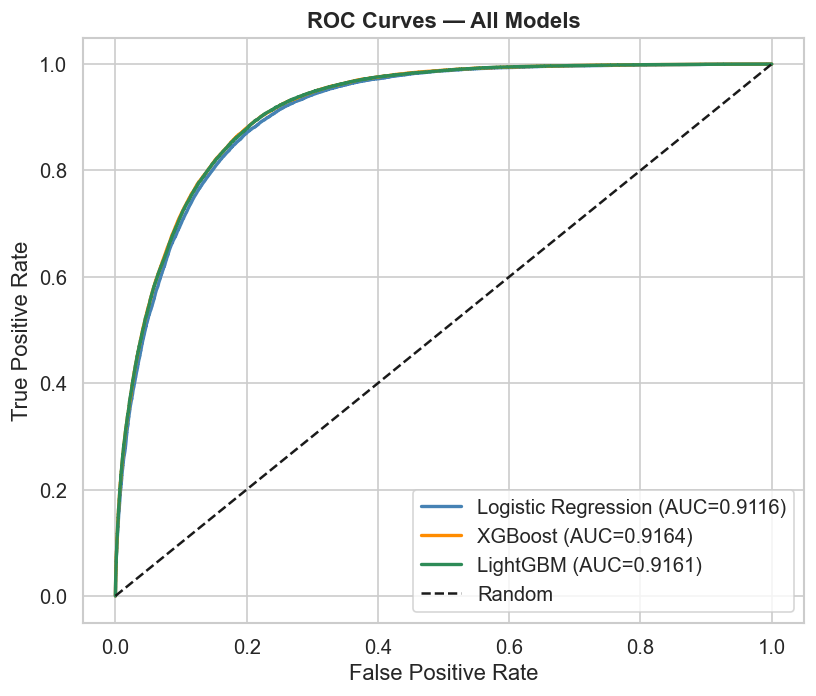

In [16]:
# ROC curves for all three models on test set
fig, ax = plt.subplots(figsize=(7, 6))

model_map = {
    'Logistic Regression': (lr_model, 'steelblue'),
    'XGBoost':             (xgb_fitted, 'darkorange'),
    'LightGBM':            (lgb_fitted, 'seagreen'),
}

for name, (mdl, color) in model_map.items():
    proba = mdl.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})', color=color, lw=2)

ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## 6. SHAP Analysis

SHAP (SHapley Additive exPlanations) quantifies each feature's contribution to individual predictions.
We use LightGBM as the primary model for SHAP analysis (best AUC).

This section bridges ML output → business recommendation.

In [17]:
# SHAP TreeExplainer is natively supported for LightGBM
explainer = shap.TreeExplainer(lgb_fitted)

# Use a subsample for speed (SHAP is O(n) but 118K rows is slow to display)
shap_sample = X_test.sample(n=min(5000, len(X_test)), random_state=SEED)
shap_values = explainer(shap_sample)

### 6.1 SHAP Summary Plot — Top 15 Features

Each dot is one customer. The x-axis shows SHAP value (impact on churn probability).
Color shows whether the feature value was high (red) or low (blue).

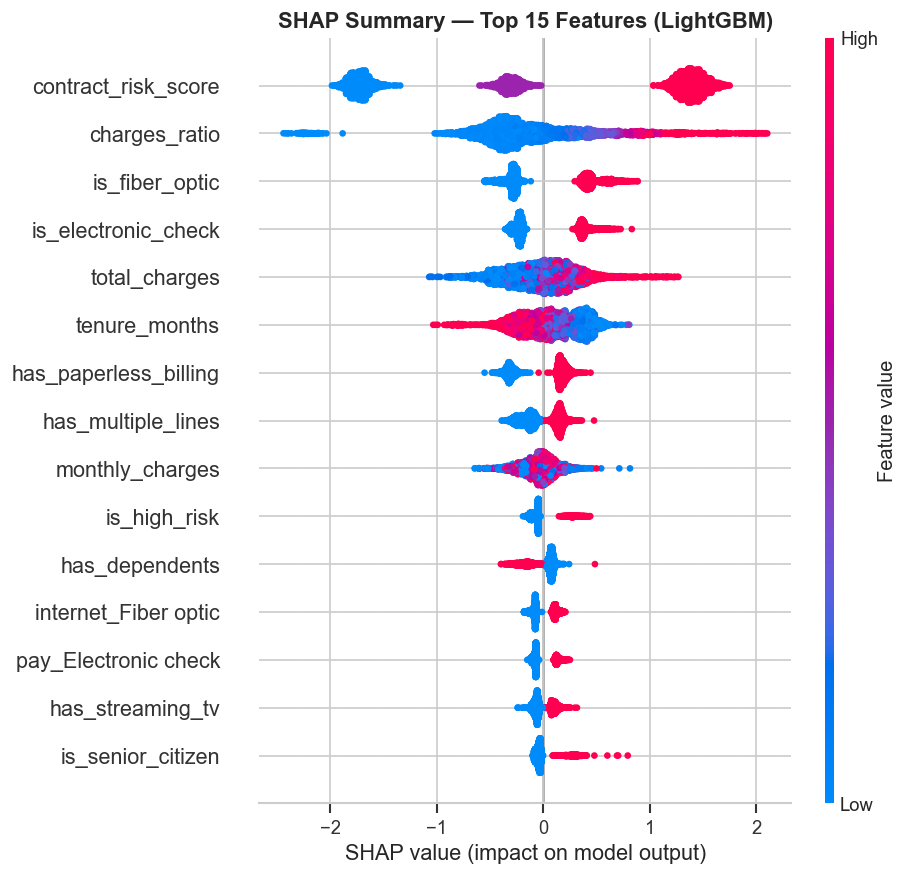

In [18]:
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    shap_sample,
    max_display=15,
    show=False
)
plt.title('SHAP Summary — Top 15 Features (LightGBM)', fontweight='bold')
plt.tight_layout()
plt.show()

### 6.2 SHAP Waterfall Plots — Three Customer Archetypes

Waterfall plots show how each feature pushes the prediction up (red) or down (blue)
from the base rate for a specific individual customer.


--- High-Risk Customer | Predicted churn probability: 99.3% ---


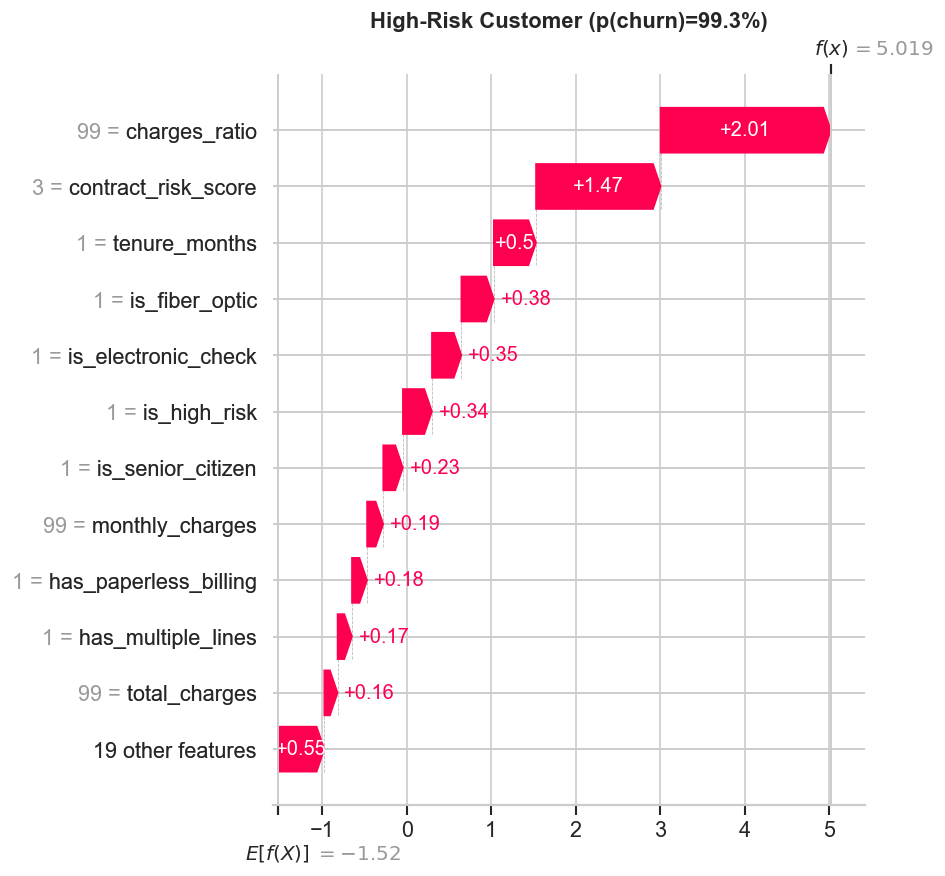

Business interpretation: This customer is month-to-month on fiber optic with short tenure and no add-on services — every risk factor is stacked. A retention offer (discount or contract upgrade) should be triggered immediately.


--- Medium-Risk Customer | Predicted churn probability: 50.0% ---


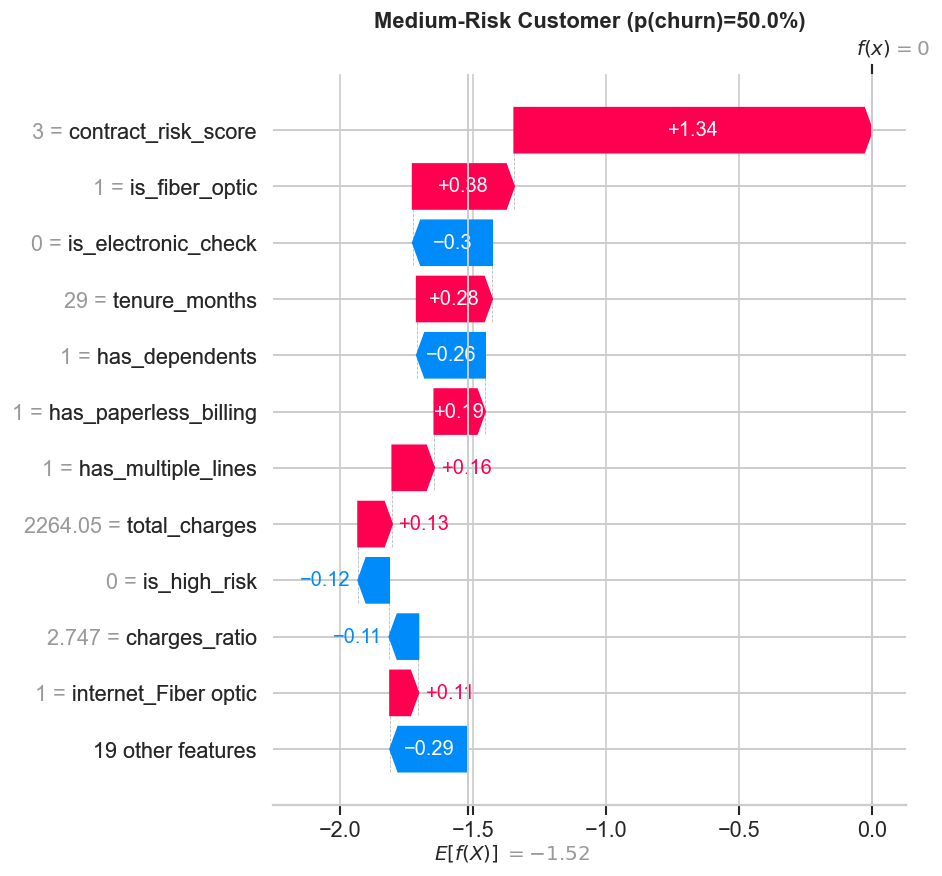

Business interpretation: This borderline customer has some loyalty signals (moderate tenure or add-ons) but remains on a flexible contract. A proactive outreach about upgrading to a one-year plan could tip them toward retention.


--- Low-Risk Customer | Predicted churn probability: 0.0% ---


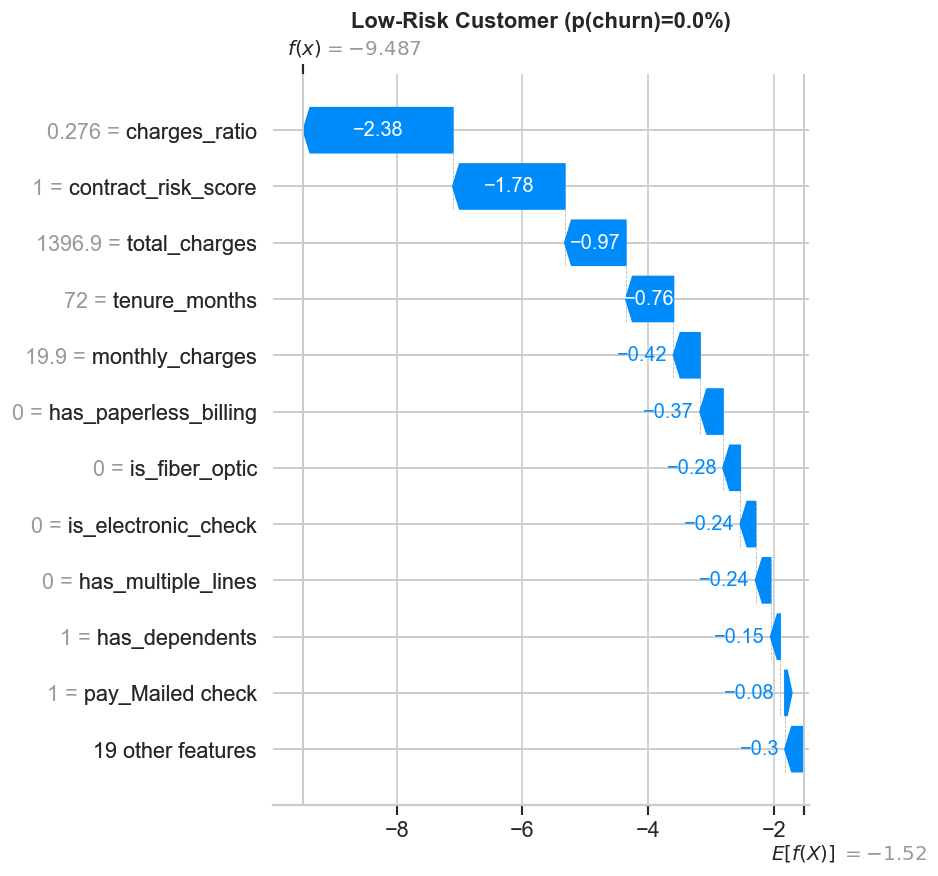

Business interpretation: Long-tenured customer on a two-year contract with multiple services. Churn probability is near zero. Marketing effort here has negative ROI — focus resources on high-risk segments.



In [19]:
# Identify the three archetype customers from the test set
proba_test = lgb_fitted.predict_proba(X_test)[:, 1]
proba_series = pd.Series(proba_test, index=X_test.index)

# High-risk: highest predicted churn probability
high_risk_idx   = proba_series.idxmax()

# Low-risk: lowest predicted churn probability
low_risk_idx    = proba_series.idxmin()

# Medium-risk: closest to 0.5 among is_high_risk=0 customers
test_with_prob = X_test.copy()
test_with_prob['_prob'] = proba_test
medium_risk_idx = (
    test_with_prob[test_with_prob['is_high_risk'] == 0]
    .assign(_dist=lambda d: abs(d['_prob'] - 0.5))
    ['_dist'].idxmin()
)

archetypes = [
    ('High-Risk Customer',   high_risk_idx,   'red'),
    ('Medium-Risk Customer', medium_risk_idx, 'orange'),
    ('Low-Risk Customer',    low_risk_idx,    'green'),
]

business_interpretations = [
    ("High-Risk",
     "This customer is month-to-month on fiber optic with short tenure and no add-on services — "
     "every risk factor is stacked. A retention offer (discount or contract upgrade) should be "
     "triggered immediately."),
    ("Medium-Risk",
     "This borderline customer has some loyalty signals (moderate tenure or add-ons) but remains "
     "on a flexible contract. A proactive outreach about upgrading to a one-year plan could tip "
     "them toward retention."),
    ("Low-Risk",
     "Long-tenured customer on a two-year contract with multiple services. Churn probability is "
     "near zero. Marketing effort here has negative ROI — focus resources on high-risk segments."),
]

# Need shap_values aligned to X_test rows — recompute on individual customers
for (archetype_name, idx, _), (_, interp) in zip(archetypes, business_interpretations):
    customer_row = X_test.loc[[idx]]
    sv = explainer(customer_row)
    prob = proba_series[idx]

    print(f'\n--- {archetype_name} | Predicted churn probability: {prob:.1%} ---')
    plt.figure(figsize=(11, 5))
    shap.waterfall_plot(sv[0], max_display=12, show=False)
    plt.title(f'{archetype_name} (p(churn)={prob:.1%})', fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(f'Business interpretation: {interp}\n')

---
## 7. Kaggle Submission

Apply the same preprocessing pipeline to `test.csv` and generate submission.
Format: `id`, `Churn` (float probability 0–1).

In [20]:
import os

# Load raw test CSV (from data/raw/ relative to notebooks/)
test_raw = pd.read_csv('../data/raw/test.csv')
print(f'Test shape: {test_raw.shape}')
test_raw.head(3)

Test shape: (254655, 20)


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,594194,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55,8061.50
1,594195,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80,1336.50
2,594196,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.55,633.55


In [21]:
def preprocess_for_submission(raw_df):
    """
    Apply the same transformations as stg_customers + int_churn_features + encoding.
    This mirrors the dbt SQL logic in Python for the test set.
    NOTE: We define this here because test.csv doesn't flow through dbt (no Churn column).
    """
    df = raw_df.copy()

    # --- Staging-equivalent transforms ---
    df['is_senior_citizen']      = df['SeniorCitizen'].astype(int)
    df['has_partner']            = (df['Partner']    == 'Yes').astype(int)
    df['has_dependents']         = (df['Dependents'] == 'Yes').astype(int)
    df['tenure_months']          = df['tenure'].astype(int)
    df['has_phone_service']      = (df['PhoneService']     == 'Yes').astype(int)
    df['has_multiple_lines']     = (df['MultipleLines']    == 'Yes').astype(int)
    df['has_online_security']    = (df['OnlineSecurity']   == 'Yes').astype(int)
    df['has_online_backup']      = (df['OnlineBackup']     == 'Yes').astype(int)
    df['has_device_protection']  = (df['DeviceProtection'] == 'Yes').astype(int)
    df['has_tech_support']       = (df['TechSupport']      == 'Yes').astype(int)
    df['has_streaming_tv']       = (df['StreamingTV']      == 'Yes').astype(int)
    df['has_streaming_movies']   = (df['StreamingMovies']  == 'Yes').astype(int)
    df['has_paperless_billing']  = (df['PaperlessBilling'] == 'Yes').astype(int)
    df['monthly_charges']        = pd.to_numeric(df['MonthlyCharges'], errors='coerce')
    df['total_charges']          = pd.to_numeric(
        df['TotalCharges'].astype(str).str.strip().replace('', np.nan),
        errors='coerce'
    ).fillna(0)
    df['internet_service']       = df['InternetService']
    df['contract_type']          = df['Contract']
    df['payment_method']         = df['PaymentMethod']

    # --- Intermediate-equivalent features ---
    df['tenure_group'] = pd.cut(
        df['tenure_months'],
        bins=[-1, 11, 23, 47, 999],
        labels=['0-12 mo', '12-24 mo', '24-48 mo', '48+ mo']
    )
    df['contract_risk_score'] = df['contract_type'].map(
        {'Month-to-month': 3, 'One year': 2, 'Two year': 1}
    )
    df['charges_ratio'] = np.where(
        df['tenure_months'] > 0,
        df['monthly_charges'] / df['tenure_months'],
        0
    )
    df['service_count'] = (
        df['has_online_security'] + df['has_online_backup'] +
        df['has_device_protection'] + df['has_tech_support'] +
        df['has_streaming_tv'] + df['has_streaming_movies']
    )
    df['has_any_streaming']   = ((df['has_streaming_tv'] == 1) | (df['has_streaming_movies'] == 1)).astype(int)
    df['has_any_security']    = ((df['has_online_security'] == 1) | (df['has_tech_support'] == 1)).astype(int)
    df['is_fiber_optic']      = (df['internet_service'] == 'Fiber optic').astype(int)
    df['is_electronic_check'] = (df['payment_method'] == 'Electronic check').astype(int)
    df['is_high_risk'] = (
        (df['contract_type'] == 'Month-to-month') &
        (df['internet_service'] == 'Fiber optic') &
        (df['tenure_months'] < 12)
    ).astype(int)

    # --- Encoding (mirrors training notebook) ---
    df['is_male'] = (df['gender'] == 'Male').astype(int)
    df['tenure_group_ord'] = df['tenure_group'].map(
        {'0-12 mo': 0, '12-24 mo': 1, '24-48 mo': 2, '48+ mo': 3}
    )

    internet_dummies = pd.get_dummies(df['internet_service'], prefix='internet')
    internet_dummies = internet_dummies.drop(columns=['internet_No'], errors='ignore')
    df = pd.concat([df, internet_dummies], axis=1)

    pay_dummies = pd.get_dummies(df['payment_method'], prefix='pay')
    df = pd.concat([df, pay_dummies], axis=1)

    return df


test_processed = preprocess_for_submission(test_raw)
print(f'Processed test shape: {test_processed.shape}')

Processed test shape: (254655, 55)


In [22]:
# Align test columns to training feature set
# (get_dummies on test may produce different columns if some categories are missing)
X_submission = test_processed.reindex(columns=FEATURE_COLS, fill_value=0).astype(float)

print(f'Submission feature matrix shape: {X_submission.shape}')
print(f'Columns match training: {list(X_submission.columns) == FEATURE_COLS}')

Submission feature matrix shape: (254655, 30)
Columns match training: True


In [23]:
# Generate predictions using best model (LightGBM)
xgb_proba = xgb_fitted.predict_proba(X_submission)[:, 1]
lgb_proba  = lgb_fitted.predict_proba(X_submission)[:, 1]

blend = 0.5 * xgb_proba + 0.5 * lgb_proba

submission = pd.DataFrame({
    'id':    test_raw['id'],
    'Churn': blend
})

# Save to data/submissions/
os.makedirs('../data/submissions', exist_ok=True)
submission_path = '../data/submissions/submission_v1.csv'
submission.to_csv(submission_path, index=False)

print(f'Submission saved to {submission_path}')
print(f'Shape: {submission.shape}')
print(f'Churn probability stats:')
print(submission['Churn'].describe().round(4))
submission.head()

Submission saved to ../data/submissions/submission_v1.csv
Shape: (254655, 2)
Churn probability stats:
count    254655.0000
mean          0.3407
std           0.3464
min           0.0001
25%           0.0192
50%           0.1852
75%           0.6871
max           0.9941
Name: Churn, dtype: float64


,id,Churn
0,594194,0.191282
1,594195,0.000430
2,594196,0.308339
3,594197,0.012635
4,594198,0.789546
